In [1]:
# Import libraries and simulation utilities
import numpy as np
import matplotlib.pyplot as plt
import sys
import os
from sim_read import *
from scipy.spatial import KDTree
import matplotlib.cm as mcm
import matplotlib.colors as mcol
from astropy.cosmology import Planck13  # Planck 2013
from astropy import units as u
from matplotlib.lines import Line2D
from matplotlib.legend import Legend


In [2]:
# Configure default matplotlib appearance
plt.rcParams["axes.linewidth"]  = 2
plt.rcParams["xtick.major.size"]  = 10
plt.rcParams["xtick.minor.size"]  = 5
plt.rcParams["ytick.major.size"]  = 10
plt.rcParams["ytick.minor.size"]  = 5
plt.rcParams["xtick.direction"]  = "in"
plt.rcParams["ytick.direction"]  = "in"
plt.rcParams["legend.frameon"] = 'False'
plt.rcParams.update({'font.size': 24})
plt.rcParams.update({'font.family': 'serif'})
plt.rcParams["mathtext.default"] = 'rm'
plt.rcParams["mathtext.fontset"] = 'cm'

In [3]:
# Load the simulation snapshot and add derived mass quantities
gls = sim(exsub_fields = ['SubhaloHalfmassRad'])
sim.mass_add(gls)

/home/tnguser/replications_and analysis/notebooks/sim_read.py:28: RuntimeWarning: divide by zero encountered in log10
/home/tnguser/replications_and analysis/notebooks/sim_read.py:29: RuntimeWarning: divide by zero encountered in log10
/home/tnguser/replications_and analysis/notebooks/sim_read.py:30: RuntimeWarning: divide by zero encountered in log10
/home/tnguser/replications_and analysis/notebooks/sim_read.py:31: RuntimeWarning: divide by zero encountered in log10


In [4]:
# Compute the star-formation main sequence and split massive/dwarf samples
sfms_intercept,sfms_slope = dwf_sfms(gls.sub.mst,gls.sub.ssfr)
massive_gal,dwarf_gal = dwf_select(gls.sub.mst)

snap_z = np.genfromtxt('snap_z_age.txt',usecols=1)
snap_tl = np.genfromtxt('snap_z_age.txt',usecols=3)

1494 10829
-8.346120696830761 -0.17679571397785238
1494 10829


In [5]:
# Define sample selection routine for primaries, secondaries, and backsplash galaxies
h0 = 0.677
dconv = 1e-3/h0
mconv = 10 - np.log10(h0)

def samp_selc(floor=7.5,thresh=9.5,NN=5,hfloor=10):
    massive_gal,dwarf_gal = dwf_select(gls.sub.mst,floor,thresh)
    all_gal = np.array([*dwarf_gal,*massive_gal])
    
    rh0 = len(all_gal)/50.0**3
    print(len(all_gal),rh0)

    back_host = np.genfromtxt('backsplash.txt',usecols=0,dtype='int')
    back_dz0 = np.genfromtxt('backsplash.txt',usecols=3,dtype='float')
    back_gal = np.genfromtxt('backsplash.txt',usecols=2,dtype='int')

    dhost = [[],[],[]]
    llg,llt,llh,llr = [[],[],[]],[[],[],[]],[[],[],[]],[[],[],[]]
    x200 = [[],[],[]]

    all_gal_pos =  gls.sub.SubhaloPos[all_gal,:]
    massive_gal_pos = gls.sub.SubhaloPos[massive_gal,:] 

    for j in back_gal:
        lh = gls.sub.SubhaloGrNr[j]
        blh = (np.where(j==back_gal)[0])[0]
        if gls.hst.group_m200[lh]>=hfloor and gls.hst.group_m200[lh]<11.5 and gls.sub.mst[j]<thresh and gls.sub.mst[j]>floor:
                #dist, ind = massive_gal_tree.query(gls.sub.SubhaloPos[j,:], k=NN+1)
                rall = wrap_dist_n(massive_gal_pos,gls.sub.SubhaloPos[j,:])
                dist,ind = np.sort(rall)[:5],np.argsort(rall)[:5]
                    
                ind = massive_gal[ind]
                dist *= dconv
                MD_mass = mconv + np.log10(gls.sub.SubhaloMass[ind])
                          
                dhost[2].append(dist[0])
                llt[2].append(max(MD_mass - 3*np.log10(dist)) - 10.96)
                llh[2].append(lh)
                llg[2].append(j)
                x200[2].append(back_dz0[blh]/gls.hst.Group_R_Crit200[back_host[blh]])
                    
                #dist0, ind0 = all_gal_tree.query(gls.sub.SubhaloPos[j,:], k=NN+1)
                rall = wrap_dist_n(all_gal_pos,gls.sub.SubhaloPos[j,:])
                dist0 = dconv*np.sort(rall)[:5]
                llr[2].append(0.2387324146*(NN+1)/dist0[-1]**3)

    dwarf_gal = np.setdiff1d(dwarf_gal,back_gal)
    
    dwarf_host,host_mem = np.unique(gls.sub.SubhaloGrNr[dwarf_gal],return_inverse=True)
    Ndh = len(dwarf_host)
    print('Ndh',Ndh)
    for i in range(Ndh):  
        lh = dwarf_host[i]
        if gls.hst.group_m200[lh]>=hfloor and gls.hst.group_m200[lh]<11.5:
            dw_mem = dwarf_gal[np.where(host_mem==i)[0]]

            stellar_sort = np.argsort(gls.sub.mst[dw_mem])
            cen = dw_mem[stellar_sort[-1]]

            if len(dw_mem)>=1 and gls.sub.mst[gls.hst.GroupFirstSub[lh]]<thresh:
                
                rall = wrap_dist_n(massive_gal_pos,gls.sub.SubhaloPos[cen,:])
                dist,ind = np.sort(rall)[:5],np.argsort(rall)[:5]

                ind = massive_gal[ind]  
                dist *= dconv
                MD_mass = mconv + np.log10(gls.sub.SubhaloMass[ind])

                dhost[0].append(dist[0])
                llt[0].append(max(MD_mass - 3*np.log10(dist)) - 10.96)
                llh[0].append(lh)
                llg[0].append(cen)
                x200[0].append(0)
                
                rall = wrap_dist_n(all_gal_pos,gls.sub.SubhaloPos[cen,:])
                dist0 = dconv*np.sort(rall)[:5]
                llr[0].append(0.2387324146*(NN+1)/dist0[-1]**3)

                if len(dw_mem)>1:
                    for j in dw_mem[stellar_sort[:-1]]:
                        rall = wrap_dist_n(massive_gal_pos,gls.sub.SubhaloPos[j,:])
                        dist,ind = np.sort(rall)[:5],np.argsort(rall)[:5]

                        ind = massive_gal[ind]  
                        dist *= dconv
                        MD_mass = mconv + np.log10(gls.sub.SubhaloMass[ind])
    
                        dhost[1].append(dist[0])
                        llt[1].append(max(MD_mass - 3*np.log10(dist)) - 10.96)
                        llh[1].append(lh)
                        llg[1].append(j)
                        x200[1].append(wrap_dist_1n(gls.sub.SubhaloPos[j,:],gls.hst.GroupPos[lh,:])/gls.hst.Group_R_Crit200[lh])

    
                        rall = wrap_dist_n(all_gal_pos,gls.sub.SubhaloPos[j,:])
                        dist0 = dconv*np.sort(rall)[:5]
                        llr[1].append(0.2387324146*(NN+1)/dist0[-1]**3)
                    
        
    return llt,llh,llg,llr,dhost,x200

In [6]:
# Execute the sample selection function for the chosen host mass floor
llt,llh,llg,llr,dhost,x200 = samp_selc(hfloor=9)

N_lll = [len(llh[k]) for k in range(3)]
print(N_lll)

1494 10829
12323 0.098584
Ndh 5585
[5003, 465, 375]


In [7]:
# Set marker and color definitions for plotting
bin_cols = ['crimson','royalblue']
bin_mk = ['o','D','s']

5003
465
375


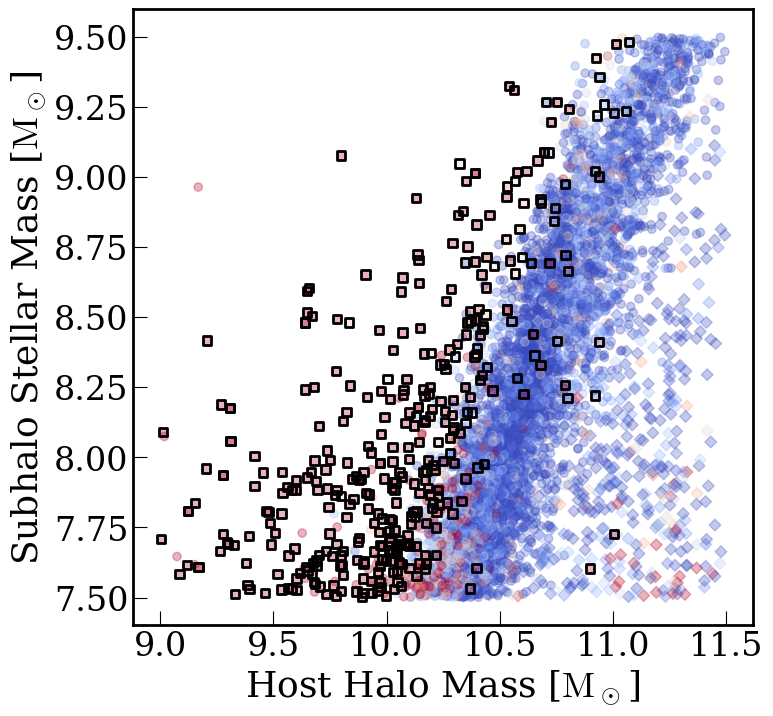

In [8]:
# Plot host halo mass versus stellar mass, colored by sSFR offset
fig,ax=plt.subplots(figsize=(8,8),sharey=True)

for k in range(3):
    mst_a = np.array([m for m in gls.sub.mst[llg[k]]])
    llh_a = np.array([gls.hst.group_m200[h] for h in llh[k]])
    ssfr_a = np.array([s for s in gls.sub.ssfr[llg[k]]])
    dsfms_a = ssfr_a-(sfms_intercept + sfms_slope*np.array(mst_a))

    ax.scatter(llh_a,mst_a,c=dsfms_a,cmap=mcm.coolwarm_r,vmin=-1, vmax=0,alpha=0.3,marker=bin_mk[k]) 
   
    if k==2:
        ax.scatter(llh_a,mst_a,c='none',edgecolors='black',marker=bin_mk[k],linewidth=2) 
    print(len(mst_a))

ax.set_xlabel('Host Halo Mass [$M_\odot$]',fontsize=26)
ax.set_ylabel('Subhalo Stellar Mass [$M_\odot$]',fontsize=26)
plt.subplots_adjust(wspace=0.0)

In [9]:
# Define helper to compute cumulative star-formation histories from a halo
def get_cumulSFH(lh,lg):
    gas = il.snapshot.loadHalo(basePath, 99, lh, 'stars', fields=fields)

    if(gas['count']!=0):
                    tree = KDTree(gas['Coordinates'])
                    close = np.array(tree.query_ball_point(gls.sub.SubhaloPos[lg,:],2*gls.sub.SubhaloHalfmassRad[lg]))

                    actual = close[np.where(gas['GFM_StellarFormationTime'][close]>0.0)[0]]

                    age = Planck13.lookback_time(np.reciprocal(gas['GFM_StellarFormationTime'][actual])-1).value
                    wts = gas['Masses'][actual]

                    sfh_hist, bin_edges = np.histogram(age,weights=wts,bins=tbins)
                    #sfh_all.append(np.cumsum(sfh_hist)/gls.sub.mst[l])
                    sfh_a = np.cumsum(sfh_hist)/np.sum(sfh_hist)
    return sfh_a


In [10]:
# Define a linear colormap helper for SFH plotting
def lc_cmap(x,cmap,vmin,vmax):
    y = (x-vmin)/(vmax-vmin)
    y[np.where(y>1)[0]] = 1
    y[np.where(y<0)[0]] = 0
    
    return cmap(y)

In [ ]:
#fig,ax=plt.subplots(figsize=(8,8))

fields = ['Coordinates','Masses','GFM_StellarFormationTime']
tbins = np.arange(0,13,0.05)

sfh_all,t50_all, t90_all = [],[],[]

for k in range(3):
    llg_a = np.array(llg[k])
    llh_a = np.array(llh[k])
    
    mst_a = np.array(gls.sub.mst[llg[k]])
    ssfr_a = np.array(gls.sub.ssfr[llg[k]])
    dsfms_a = ssfr_a-(sfms_intercept + sfms_slope*np.array(mst_a))
    
    sfh_a = np.zeros((N_lll[k],len(tbins)-1))
    t50_a,t90_a =  np.zeros(N_lll[k]), np.zeros(N_lll[k])

    dwarf_host,host_mem = np.unique(llh_a,return_inverse=True)
    print(len(llg_a),len(host_mem))
    
    dsfms_col = lc_cmap(dsfms_a,mcm.coolwarm_r,-1,0)
    
    Ndh = len(dwarf_host)
    for i in range(Ndh):  
        lh = dwarf_host[i]
        dw_mem = np.where(host_mem==i)[0]
        stars = il.snapshot.loadHalo(basePath, 99, lh, 'stars', fields=fields)
    
        if(stars['count']!=0):
            tree = KDTree(stars['Coordinates'])
            
            for l in dw_mem:
                lg = llg_a[l]
                close = np.array(tree.query_ball_point(gls.sub.SubhaloPos[lg,:],2*gls.sub.SubhaloHalfmassRad[lg]))
                actual = close[np.where(stars['GFM_StellarFormationTime'][close]>0.0)[0]]

                age = Planck13.lookback_time(np.reciprocal(stars['GFM_StellarFormationTime'][actual])-1).value
                wts = stars['Masses'][actual]

                sfh_hist, bin_edges = np.histogram(age,weights=wts,bins=tbins)
                #sfh_all.append(np.cumsum(sfh_hist)/gls.sub.mst[l])
                sfh_a[l,:] = 1 - np.cumsum(sfh_hist)/np.sum(sfh_hist)
                t50_a[l] = min(tbins[np.where(sfh_a[l,:]<0.5)[0]])
                t90_a[l] = min(tbins[np.where(sfh_a[l,:]<0.9)[0]])
    
                #ax.plot(tbins[:-1],sfh_a[l,:],c=dsfms_col[l],lw=2,alpha=0.3)
        
    sfh_all.append(sfh_a)
    t50_all.append(t50_a)
    t90_all.append(t90_a)
   
        
#ax.invert_xaxis()   

5003 5003


In [ ]:
# Plot the cumulative SFHs for each selected galaxy sample
fig,ax=plt.subplots(figsize=(8,8))


for k in range(3):
    llg_a = np.array([l for l in llg[k]])
    llh_a = np.array([h for h in llh[k]])

    mst_a = np.array([m for m in gls.sub.mst[llg[k]]])
    ssfr_a = np.array([s for s in gls.sub.ssfr[llg[k]]])
    dsfms_a = ssfr_a-(sfms_intercept + sfms_slope*np.array(mst_a))
    
    dsfms_col = lc_cmap(dsfms_a,mcm.coolwarm_r,-1,0)
    
    for i in range(len(llg_a)):
        ax.plot(tbins[:-1],sfh_all[k][i],c=dsfms_col[i],lw=2,alpha=0.3)
        
ax.invert_xaxis() 
ax.set_xlabel(r'$Lookback\ Time\ (Gyr)$',fontsize=32)
ax.set_ylabel(r'$Cumulative\ SFH$',fontsize=32)

plt.tight_layout()
plt.show()


In [ ]:
# Plot SFH percentile bands and medians for the three samples
fig,ax=plt.subplots(1,4,figsize=(24,8),sharey=True,width_ratios=[0.33,0.33,0.33,0.01])
tbins = np.arange(0,13,0.05)


for k in range(3):
    mst_a = np.array([m for m in gls.sub.mst[llg[k]]])
    ssfr_a = np.array([s for s in gls.sub.ssfr[llg[k]]])
    dsfms_a = ssfr_a-(sfms_intercept + sfms_slope*np.array(mst_a))
    
    dsfms_col = lc_cmap(dsfms_a,mcm.coolwarm_r,-1,0)
    print(len(sfh_all[k]))
        
    for i in range(len(sfh_all[k])):
        
        ax[k].plot(tbins[:-1],sfh_all[k][i],c=dsfms_col[i],lw=2,alpha=0.2)
        
    t50_med,t90_med = np.mean(t50_all[k]),np.mean(t90_all[k])
    t50_std,t90_std = np.std(t50_all[k],ddof=1),np.std(t90_all[k],ddof=1)

    print(k,'t50:',t50_med,'+/-',t50_std,'t90',t90_med,'+/-',t90_std)
    
    ax[k].axvline(t50_med,color='lime',lw=3,alpha=0.8)
    ax[k].fill_betweenx([0,1],t50_med-t50_std,t50_med+t50_std,color='lime',alpha=0.1)
    ax[k].axvline(t90_med,color='yellow',lw=3,alpha=0.8)
    ax[k].fill_betweenx([0,1],t90_med-t90_std,t90_med+t90_std,color='yellow',alpha=0.1)
        
    csfh10 = np.percentile(np.array(sfh_all[k]), 10,axis=0)
    csfh50 = np.percentile(np.array(sfh_all[k]), 50,axis=0)
    csfh90 = np.percentile(np.array(sfh_all[k]), 90,axis=0)
    
    ax[k].plot(tbins[:-1],csfh50,color='black',lw=4)
    ax[k].plot(tbins[:-1],csfh10,color='black',lw=4,ls='--')
    ax[k].plot(tbins[:-1],csfh90,color='black',lw=4,ls='--')
      
    ax[k].invert_xaxis() 
    ax[k].set_rasterized(True)
    ax[k].set_xlabel(r'$Lookback\ Time\ (Gyr)$',fontsize=36)
    
ax[0].set_ylabel(r'$Cumulative\ SFH$',fontsize=36)
ax[3].set_axis_off()
fig.colorbar(mcm.ScalarMappable(norm=mcol.Normalize(vmin=-1, vmax=0),cmap=mcm.coolwarm_r), ax=ax[3], orientation='vertical',fraction=2.2,label=r'$\Delta\ log(sSFR/yr^{-1})$')

ax[0].text(12.5,0.9,r'$Primaries$',fontsize=36)
ax[1].text(12.5,0.9,r'$Secondaries$',fontsize=36)
ax[2].text(6,0.1,r'$Backsplash$',fontsize=36)

plt.subplots_adjust(wspace=0.0)
plt.savefig('lmc_cmsh.pdf',bbox_inches='tight')



In [ ]:
# Combine t50 and t90 values across all samples and print counts
t50_a = np.array([t for k in range(3) for t in t50_all[k]])
t90_a = np.array([t for k in range(3) for t in t90_all[k]])
print(len(t50_a),len(t90_a))

ssfr_a = np.array([s for i in range(3) for s in gls.sub.ssfr[llg[i]]])
mst_a = np.array([m for i in range(3) for m in gls.sub.mst[llg[i]]])
dsfms_a = ssfr_a-(sfms_intercept + sfms_slope*np.array(mst_a))
    
red_a = np.where(dsfms_a<-1)[0]
blue_a = np.where(dsfms_a>=-1)[0]
print(len(red_a),len(blue_a))

In [ ]:
# Separate red and blue subsamples based on sSFR offset
redt50_med,bluet50_med = np.mean(t50_a[red_a]),np.mean(t50_a[blue_a])
redt90_med,bluet90_med = np.mean(t90_a[red_a]),np.mean(t90_a[blue_a])

redt50_std,bluet50_std = np.std(t50_a[red_a],ddof=1),np.std(t50_a[blue_a],ddof=1)
redt90_std,bluet90_std = np.std(t90_a[red_a],ddof=1),np.std(t90_a[blue_a],ddof=1)

print('red_t50:',redt50_med,'+/-',redt50_std,'blue_t50',bluet50_med,'+/-',bluet50_std)
print('red_t90:',redt90_med,'+/-',redt50_std,'blue_t90',bluet90_med,'+/-',redt50_std)

In [ ]:
# Plot histograms of t50 and t90 for the three galaxy samples
fig,ax=plt.subplots(1,3,figsize=(24,8),sharey=True)

tbins_coarse = tbins = np.arange(0,13,1)


for k in range(3):
    t50_hist, bin_edges = np.histogram(t50_all[k],bins=tbins_coarse)
    t90_hist, bin_edges = np.histogram(t90_all[k],bins=tbins_coarse)
    
    ax[k].step(tbins[:-1],t50_hist/len(t50_all[k]),color='black',ls='--',lw=2,where='mid',label=r'$\tau_{50}$')
    ax[k].step(tbins[:-1],t90_hist/len(t90_all[k]),color='black',lw=2,where='mid',label=r'$\tau_{90}$')

    ax[k].set_xlabel(r'$Lookback\ Time\ (Gyr)$',fontsize=28)
ax[0].set_ylabel(r'$Fraction$',fontsize=28)

ax[0].legend(loc='best',fontsize=28,framealpha=0.8,frameon=True)

plt.subplots_adjust(wspace=0.0) 



In [ ]:
# Create environment correlation plots for quenching times and halo properties
fig,ax=plt.subplots(2,2,figsize=(18,16),sharey=True)

tracer_bins = [np.logspace(np.log10(0.2),np.log10(12),7),np.linspace(-3,3,7)]
tracer_bw = [0.5*(tb[1]-tb[0]) for tb in tracer_bins]
bin_mk = ['o','D','s']

dhost_bins = np.logspace(np.log10(0.15),np.log10(15),11)
llt_bins = np.linspace(-5,3,11)

for k in range(3):
    mst_a = np.array([m for m in gls.sub.mst[llg[k]]])
    ssfr_a = np.array([s for s in gls.sub.ssfr[llg[k]]])
    dsfms_a = ssfr_a-(sfms_intercept + sfms_slope*np.array(mst_a))
    
    ax[0,1].scatter(llt[k],t50_all[k],marker=bin_mk[k],c=dsfms_a,cmap=mcm.coolwarm_r,vmin=-1, vmax=0,alpha=0.3,s=60)
    ax[0,0].scatter(dhost[k],t50_all[k],marker=bin_mk[k],c=dsfms_a,cmap=mcm.coolwarm_r,vmin=-1, vmax=0,alpha=0.3,s=60)
   
    ax[1,1].scatter(llt[k],t90_all[k],marker=bin_mk[k],c=dsfms_a,cmap=mcm.coolwarm_r,vmin=-1, vmax=0,alpha=0.3,s=60)
    ax[1,0].scatter(dhost[k],t90_all[k],marker=bin_mk[k],c=dsfms_a,cmap=mcm.coolwarm_r,vmin=-1, vmax=0,alpha=0.3,s=60)
    
    
    if k==1:
        ax[0,1].scatter(llt[k],t50_all[k],c='none',edgecolors='black',marker=bin_mk[k],linewidth=1.5,alpha=0.5,s=60) 
        ax[0,0].scatter(dhost[k],t50_all[k],c='none',edgecolors='black',marker=bin_mk[k],linewidth=1.5,alpha=0.5,s=60)
        
        ax[1,1].scatter(llt[k],t90_all[k],c='none',edgecolors='black',marker=bin_mk[k],linewidth=1.5,alpha=0.5,s=60) 
        ax[1,0].scatter(dhost[k],t90_all[k],c='none',edgecolors='black',marker=bin_mk[k],linewidth=1.5,alpha=0.5,s=60)  

    if k==2:
        ax[0,1].scatter(llt[k],t50_all[k],c='none',edgecolors='black',marker=bin_mk[k],linewidth=2,s=60,alpha=0.8) 
        ax[0,0].scatter(dhost[k],t50_all[k],c='none',edgecolors='black',marker=bin_mk[k],linewidth=2,s=60,alpha=0.8) 
        
        ax[1,1].scatter(llt[k],t90_all[k],c='none',edgecolors='black',marker=bin_mk[k],linewidth=2,s=60,alpha=0.8) 
        ax[1,0].scatter(dhost[k],t90_all[k],c='none',edgecolors='black',marker=bin_mk[k],linewidth=2,s=60,alpha=0.8) 

llt_a = np.array([t for i in range(3) for t in llt[i]])
dhost_a = np.array([d for i in range(3) for d in dhost[i]])
t50_a = np.array([t for i in range(3) for t in t50_all[i]])
t90_a = np.array([d for i in range(3) for d in t90_all[i]])

xticks = [0.2,0.5,1.0, 2,4]
xlabels = [f'${x:1.1f}$' for x in xticks]

qnc_ind = [red_a,blue_a]
qnc_col = ['coral','turquoise']

for k in range(2):
    ax[k,0].set_xlim((0.2,12))
    ax[k,1].set_xlim((3.2,-3.2))
    
    bin_qnc, bin_edg, bin_n = sts.binned_statistic(dhost_a[qnc_ind[k]],t50_a[qnc_ind[k]],statistic='median', bins=tracer_bins[0])
    ax[0,0].plot(tracer_bins[0][:-1]+tracer_bw[0],bin_qnc,lw=4,marker='o',color=qnc_col[k],markersize=18,markeredgecolor='white',markeredgewidth=2)


    bin_qnc, bin_edg, bin_n = sts.binned_statistic(dhost_a[qnc_ind[k]],t90_a[qnc_ind[k]],statistic='median', bins=tracer_bins[0])
    ax[1,0].plot(tracer_bins[0][:-1]+tracer_bw[0],bin_qnc,lw=4,marker='o',color=qnc_col[k],markersize=18,markeredgecolor='white',markeredgewidth=2)

    bin_qnc, bin_edg, bin_n = sts.binned_statistic(llt_a[qnc_ind[k]],t50_a[qnc_ind[k]],statistic='median', bins=tracer_bins[1])
    ax[0,1].plot(tracer_bins[1][:-1]+tracer_bw[1],bin_qnc,lw=4,marker='o',color=qnc_col[k],markersize=18,markeredgecolor='white',markeredgewidth=2)

    bin_qnc, bin_edg, bin_n = sts.binned_statistic(llt_a[qnc_ind[k]],t90_a[qnc_ind[k]],statistic='median', bins=tracer_bins[1])
    ax[1,1].plot(tracer_bins[1][:-1]+tracer_bw[1],bin_qnc,lw=4,marker='o',color=qnc_col[k],markersize=18,markeredgecolor='white',markeredgewidth=2)
    
    ax[k,0].axvline(1.5,color='black',ls='--')
    ax[k,1].axvline(0,color='black',ls='--')

    #ax[0,2].set_axis_off()
    #ax[1,2].set_axis_off()
    
    ax[k,0].set_xticks(xticks, labels=xlabels,fontsize=28)

    #ax[k,1].invert_xaxis()
    ax[k,0].set_xscale('log')
    
    ax[0,k].set_rasterized(True)
    ax[1,k].set_rasterized(True)
        
ax[1,0].set_xlabel(r'$d_{massive}\ [Mpc]$',fontsize=36)
ax[1,1].set_xlabel(r'$\Theta_1$',fontsize=36)
    
ax[0,0].set_ylabel(r'$\tau_{50} (Gyr)$',fontsize=36)
ax[1,0].set_ylabel(r'$\tau_{90} (Gyr)$',fontsize=36)

custom_lines = [Line2D([0], [0],lw=3,ls='none',marker='o', color='coral',markersize=18), Line2D([0], [0],lw=3,ls='none',marker='o', color='turquoise',markersize=18)]
leg=Legend(ax[1,0],custom_lines,[r'$Quenched$'+'\n'+r'$Median$',r'$Star-forming$'+'\n'+r'$Median$'],loc='best',fontsize=26,framealpha=0.8,frameon=True)
ax[1,0].add_artist(leg)

custom_lines = [Line2D([0], [0],lw=3,ls='none',marker=bin_mk[0], color='black',markersize=10), Line2D([0], [0],lw=3,ls='none',marker=bin_mk[1], color='black',markersize=10), Line2D([0], [0],lw=3,ls='none',marker=bin_mk[2], color='black',markersize=10)]
leg=Legend(ax[1,1],custom_lines,[r'$primaries$',r'$secondaries$',r'$backsplash$'],loc='best',fontsize=30,framealpha=0.8,frameon=True)
ax[1,1].add_artist(leg)
          
fig.subplots_adjust(right=0.98)
cbar_ax = fig.add_axes([0.99, 0.1, 0.02, 0.75])
fig.colorbar(mcm.ScalarMappable(norm=mcol.Normalize(vmin=-1, vmax=0),cmap=mcm.coolwarm_r),cax=cbar_ax,label=r'$\Delta\ log(sSFR/yr^{-1})$')
plt.subplots_adjust(wspace=0.0,hspace=0.1)      
plt.savefig('quenchtime_env.pdf',bbox_inches='tight')


In [ ]:
# Define helper function to compute gas fraction history along subhalo merger trees
sat_fields = ['SubhaloMassInRadType','SnapNum']
tbins = np.arange(0,13,0.05)


def get_gasfracH(lg):
    gas_frac = np.zeros((len(lg),100))
    
    for l in range(len(lg)):
        try:
            sat_tree = il.sublink.loadTree(basePath, 99, lg[l], fields=sat_fields, onlyMPB=True)
            Nbranch = len(sat_tree['SnapNum'])
        except: continue

        if Nbranch>40:
            gas_frac[l,sat_tree['SnapNum']] = sat_tree['SubhaloMassInRadType'][:,0]/(sat_tree['SubhaloMassInRadType'][:,0]+sat_tree['SubhaloMassInRadType'][:,4])
            
    return gas_frac
